# Notebook 05c - BioBERT Fine-Tuning

## Environment Setup and Library Imports

This section initialises the environment and imports all required libraries and configuration parameters for the BioBERT training pipeline.

- Extends the Python path to enable access to project modules from the parent directory
- Imports core libraries for data manipulation, model training, evaluation, and visualisation
- Loads experiment configuration parameters for consistency and reproducibility

In [1]:
# System Path Configuration
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

# Core Data Handling Libraries
import pandas as pd
import numpy as np
import pickle

# PyTorch Utilities
import torch
from torch.utils.data import Dataset

# Visualisation and Warning Control
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Hugging Face Transformers Components
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    set_seed,
)

# Scikit-learn Utilities
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    ConfusionMatrixDisplay,
)

# Evaluation Library
import evaluate

# Project Configuration Parameters
from config import (
    LABELLED_DATASET,
    BIOBERT_MODEL_ID,
    BIOBERT_DIR,
    BIOBERT_RESULTS_CSV,
    BIOBERT_PREDS_PKL,
    PLOTS_DIR,
    MAX_LENGTH,
    NUM_EPOCHS,
    BATCH_SIZE,
    LEARNING_RATE,
    WEIGHT_DECAY,
    WARMUP_STEPS,
    EARLY_STOPPING_PATIENCE,
    RANDOM_STATE,
    TEST_SIZE,
    VAL_SIZE,
    NUM_LABELS,
)


# Create BioBERT Plot Save Directory
BIOBERT_PLOTS_DIR = PLOTS_DIR / "biobert_model"
BIOBERT_PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# Global Plotting Style
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False
})

# Colour Palette for Visualisations
PALETTE = ['#2E86AB', '#E84855', '#F4A261', '#2A9D8F', '#8338EC']

## Reproducibility, Data Preparation, and Class Imbalance Handling

This section initialises reproducibility settings, prepares the dataset, and computes class weights.

- Sets a fixed random seed and configures cuDNN for GPU optimisation
- Loads the labelled dataset and creates a stratified train/validation/test split using the same random seed as Notebooks 05a and 05b, ensuring identical test sets across all models for fair comparison
- Computes class weights to handle label imbalance

In [2]:
# Reproducibility Setup
set_seed(RANDOM_STATE)

# cuDNN Configuration for Performance Optimisation
torch.backends.cudnn.benchmark = True
torch.backends.cudnn.deterministic = False

# Device Selection (GPU if available, else CPU)
device   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_FP16 = (device.type == 'cuda')

# Dataset Loading
df = pd.read_csv(LABELLED_DATASET)

# Feature and Label Extraction
X = df['narrative'].to_numpy(dtype=str)
y = df['readmission_30d'].to_numpy(dtype=int)

# Train / Validation / Test Split (Stratified -- identical seed to 05a and 05b)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=VAL_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

# Class Weight Computation (Handling Imbalance)
cw_arr = compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)

cw_dict = {
    0: float(cw_arr[0]),
    1: float(cw_arr[1])
}

# Dataset Summary Statistics
print(f'Train : {len(X_train):,}  |  Val : {len(X_val):,}  |  Test : {len(X_test):,}')
print(f'Train label dist : {np.bincount(y_train)}')
print(f'Class weights : {cw_dict}')

Train : 11,561  |  Val : 1,445  |  Test : 1,446
Train label dist : [9301 2260]
Class weights : {0: 0.6214923126545533, 1: 2.557743362831858}


## Cased Vocabulary Analysis

This section highlights the key distinction of BioBERT from the other models: its cased vocabulary.

BioBERT is initialised from BERT-base-cased and then continued pre-training on PubMed abstracts and PMC full-text (approximately 18 billion tokens). Unlike DistilBERT and PubMedBERT which use uncased vocabularies, BioBERT preserves uppercase and lowercase distinctions.

This is clinically significant because capitalisation carries meaning in medical text:
- ICU (intensive care unit) vs icu
- Mg (magnesium element) vs mg (milligrams)
- HE (hepatic encephalopathy) vs he (pronoun)
- K (potassium) vs k

The cased tokeniser can preserve these distinctions as distinct tokens, potentially providing additional signal for clinical NLP tasks.

In [3]:
# Tokeniser Loading
tokenizer = AutoTokenizer.from_pretrained(BIOBERT_MODEL_ID)

# Cased Vocabulary Demonstration
print('BioBERT cased tokenisation -- clinically meaningful distinctions:\n')

cased_examples = [
    ('ICU stay',     'icu stay',     'ICU = intensive care unit'),
    ('Mg 2.1 meq/L', 'mg 2.1 meq/L', 'Mg = magnesium element'),
    ('HE grade 2',   'he grade 2',   'HE = hepatic encephalopathy'),
    ('K+ low',       'k+ low',       'K = potassium'),
    ('T 38.4',       't 38.4',       'T = temperature'),
]

print(f'{"Original":<20}  {"Lowercased":<20}  {"Tokens differ?"}')
print('-' * 65)

for orig, lower, note in cased_examples:
    t_orig  = tokenizer.tokenize(orig)
    t_lower = tokenizer.tokenize(lower)
    diff = f'YES  ({note})' if t_orig != t_lower else 'same'
    print(f'{orig:<20}  {lower:<20}  {diff}')

print('\n-> Cased vocabulary preserves clinically meaningful distinctions.')
print('   Uncased models (DistilBERT, PubMedBERT) cannot distinguish these.')

BioBERT cased tokenisation -- clinically meaningful distinctions:

Original              Lowercased            Tokens differ?
-----------------------------------------------------------------
ICU stay              icu stay              YES  (ICU = intensive care unit)
Mg 2.1 meq/L          mg 2.1 meq/L          YES  (Mg = magnesium element)
HE grade 2            he grade 2            YES  (HE = hepatic encephalopathy)
K+ low                k+ low                YES  (K = potassium)
T 38.4                t 38.4                YES  (T = temperature)

-> Cased vocabulary preserves clinically meaningful distinctions.
   Uncased models (DistilBERT, PubMedBERT) cannot distinguish these.


## Tokenisation and Dataset Preparation

This section creates the tokenised datasets using the BioBERT cased tokeniser.

- Uses the BioBERT tokeniser loaded in the previous section
- Defines a PyTorch dataset class for encoding and label handling
- Creates dataset objects for training, validation, and test sets

In [4]:
# Custom PyTorch Dataset for Tokenised Inputs
class ClinicalDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=MAX_LENGTH):
        # Text Tokenisation (Padding + Truncation)
        self.enc = tokenizer(
            list(texts),
            truncation=True,
            padding='max_length',
            max_length=max_length,
            return_tensors='pt'
        )
        # Label Tensor Conversion
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        # Dataset Size
        return len(self.labels)

    def __getitem__(self, idx):
        # Retrieve Encoded Inputs and Corresponding Label
        item = {k: v[idx] for k, v in self.enc.items()}
        item['labels'] = self.labels[idx]
        return item

# Dataset Instantiation (Train / Validation / Test)
train_ds = ClinicalDataset(X_train, y_train, tokenizer)
val_ds   = ClinicalDataset(X_val,   y_val,   tokenizer)
test_ds  = ClinicalDataset(X_test,  y_test,  tokenizer)

# Confirmation Output
print(f'Datasets created  (max_length={MAX_LENGTH})')

Datasets created  (max_length=256)


## Custom Trainer and Evaluation Metrics

This section defines the custom weighted trainer and evaluation metrics, identical in structure to Notebooks 05a and 05b for consistency.

In [5]:
# Custom Trainer with Class-Weighted Loss
class WeightedTrainer(Trainer):
    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)

        # Class Weight Tensor (Moved to Device)
        w = torch.tensor(
            [class_weights[0], class_weights[1]],
            dtype=torch.float
        ).to(device)

        # Weighted Cross-Entropy Loss
        self.loss_fn = torch.nn.CrossEntropyLoss(weight=w)

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        # Extract Labels and Forward Pass
        labels  = inputs.pop('labels')
        outputs = model(**inputs)

        # Compute Weighted Loss
        loss = self.loss_fn(outputs.logits, labels)

        return (loss, outputs) if return_outputs else loss


# Accuracy Metric Initialisation
acc_metric = evaluate.load('accuracy')


# Evaluation Metrics Function
def compute_metrics(eval_pred):
    logits, labels = eval_pred

    # Predictions and Probabilities
    preds = np.argmax(logits, axis=-1)
    probs = torch.softmax(
        torch.tensor(logits, dtype=torch.float32),
        dim=-1
    ).numpy()[:, 1]

    # Accuracy Computation
    acc = acc_metric.compute(
        predictions=preds,
        references=labels
    )['accuracy']

    # Classification Report (Weighted F1)
    rep = classification_report(
        labels,
        preds,
        output_dict=True,
        zero_division=0
    )

    # ROC-AUC and PR-AUC (with Safe Handling)
    try:
        roc = roc_auc_score(labels, probs)
        pr  = average_precision_score(labels, probs)
    except ValueError:
        roc = pr = 0.0

    # Metric Dictionary
    return {
        'accuracy'    : acc,
        'f1_weighted' : rep['weighted avg']['f1-score'],
        'roc_auc'     : roc,
        'pr_auc'      : pr,
    }

## Model Initialisation and Resource Profiling

This section initialises BioBERT for sequence classification and profiles its computational footprint.

In [6]:
# GPU Memory Check (Before Model Loading)
if device.type == 'cuda':
    torch.cuda.empty_cache()
    vram_before = torch.cuda.memory_allocated(0) / 1e9

# Model Initialisation (Sequence Classification Head)
model = AutoModelForSequenceClassification.from_pretrained(
    BIOBERT_MODEL_ID,
    num_labels=NUM_LABELS
)

# Move Model to Device
model.to(device)

# GPU Memory Check (After Model Loading)
if device.type == 'cuda':
    vram_after = torch.cuda.memory_allocated(0) / 1e9
    print(f'VRAM before : {vram_before:.2f} GB')
    print(f'VRAM after  : {vram_after:.2f} GB  (model footprint {vram_after - vram_before:.2f} GB)')

# Parameter Count (Total and Trainable)
total_p     = sum(p.numel() for p in model.parameters())
trainable_p = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'Parameters  : {total_p:,} total  |  {trainable_p:,} trainable')

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 703.90it/s, Materializing param=bert.pooler.dense.weight]                               
BertForSequenceClassification LOAD REPORT from: dmis-lab/biobert-base-cased-v1.2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:

VRAM before : 0.00 GB
VRAM after  : 0.43 GB  (model footprint 0.43 GB)
Parameters  : 108,311,810 total  |  108,311,810 trainable


## Training Configuration and Model Fine-Tuning

This section defines the training configuration and executes BioBERT fine-tuning using the same hyperparameters as the other transformer notebooks for fair comparison.

In [7]:
# Training Arguments Configuration
training_args = TrainingArguments(
    output_dir                  = BIOBERT_DIR,
    num_train_epochs            = NUM_EPOCHS,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE * 2,
    learning_rate               = LEARNING_RATE,
    warmup_steps                = WARMUP_STEPS,
    weight_decay                = WEIGHT_DECAY,
    eval_strategy               = 'epoch',
    save_strategy               = 'epoch',
    load_best_model_at_end      = True,
    metric_for_best_model       = 'roc_auc',
    greater_is_better           = True,
    fp16                        = USE_FP16,
    dataloader_pin_memory       = (device.type == 'cuda'),
    dataloader_num_workers      = 0,
    logging_steps               = 50,
    report_to                   = 'none',
    seed                        = RANDOM_STATE,
)

# Trainer Initialisation
trainer = WeightedTrainer(
    class_weights   = cw_dict,
    model           = model,
    args            = training_args,
    train_dataset   = train_ds,
    eval_dataset    = val_ds,
    compute_metrics = compute_metrics,
    callbacks       = [
        EarlyStoppingCallback(
            early_stopping_patience=EARLY_STOPPING_PATIENCE
        )
    ],
)

# Training Start Notification
print('Starting BioBERT fine-tuning...')

# Pre-Training GPU Memory Check
if device.type == 'cuda':
    print(f'VRAM before training : {torch.cuda.memory_allocated(0)/1e9:.2f} GB')

# Model Training Execution
train_result = trainer.train()

# Training Runtime Summary
runtime_min = train_result.metrics['train_runtime'] / 60
print(f'Training complete in {runtime_min:.1f} min')

# Peak GPU Memory Usage
if device.type == 'cuda':
    peak = torch.cuda.max_memory_allocated(0) / 1e9
    print(f'Peak VRAM : {peak:.2f} GB')
    torch.cuda.reset_peak_memory_stats()

Starting BioBERT fine-tuning...
VRAM before training : 0.43 GB


Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted,Roc Auc,Pr Auc
1,0.682643,0.636869,0.582007,0.624477,0.690782,0.362405
2,0.649285,0.622276,0.741176,0.751934,0.724725,0.409496
3,0.613840,0.672137,0.764706,0.768560,0.723145,0.427117
4,0.613923,0.622026,0.667820,0.699602,0.715756,0.430614
5,0.561279,0.648162,0.580623,0.623233,0.720489,0.450263


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.48s/it]
There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer

Training complete in 10.2 min
Peak VRAM : 4.91 GB


## Training Curve Visualisation

This section extracts logged training metrics and visualises model performance over fine-tuning epochs.

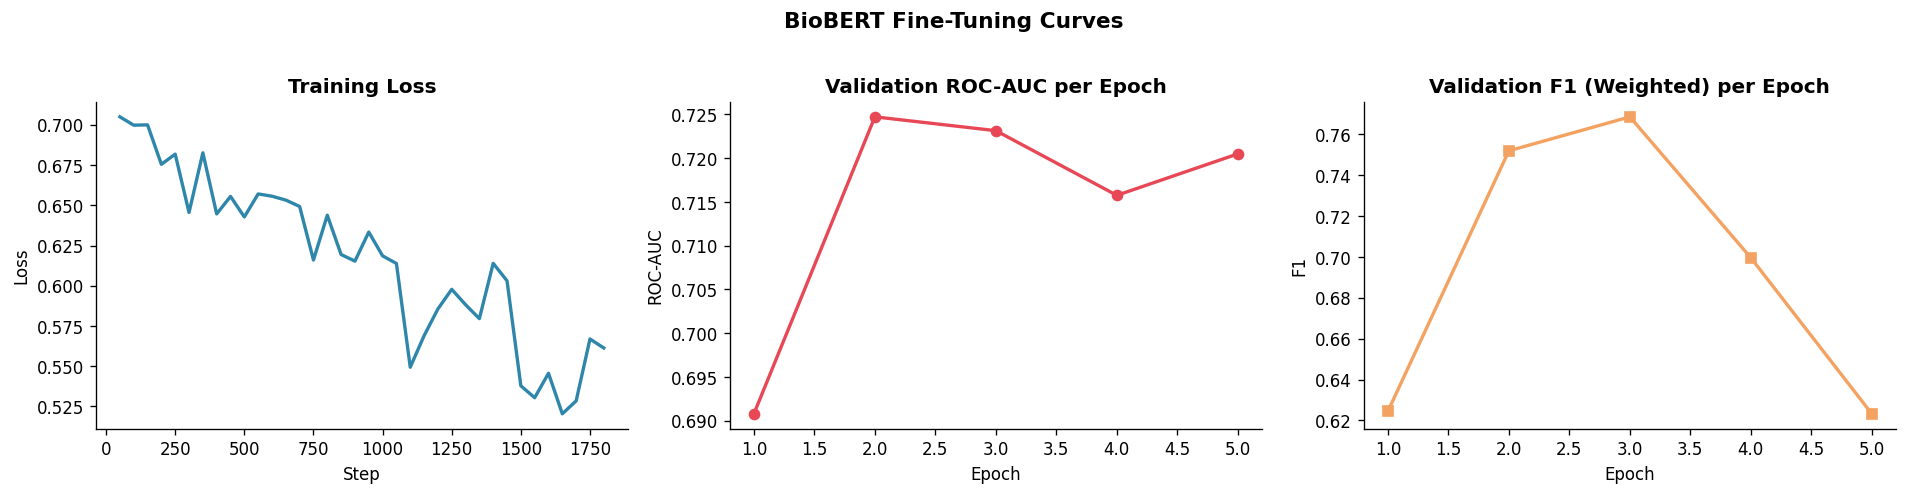

In [8]:
# Extract Training and Evaluation Logs
log_history = trainer.state.log_history

train_logs = [
    x for x in log_history
    if 'loss' in x and 'eval_loss' not in x
]

eval_logs = [
    x for x in log_history
    if 'eval_loss' in x
]

# Plot Training Curves (If Logs Available)
if train_logs and eval_logs:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # Training Loss vs Steps
    axes[0].plot(
        [x['step'] for x in train_logs],
        [x['loss'] for x in train_logs],
        color=PALETTE[0],
        lw=2
    )
    axes[0].set_title('Training Loss', fontweight='bold')
    axes[0].set_xlabel('Step')
    axes[0].set_ylabel('Loss')

    # Validation ROC-AUC per Epoch
    axes[1].plot(
        [x['epoch'] for x in eval_logs],
        [x.get('eval_roc_auc', 0) for x in eval_logs],
        'o-',
        color=PALETTE[1],
        lw=2,
        markersize=6
    )
    axes[1].set_title('Validation ROC-AUC per Epoch', fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('ROC-AUC')

    # Validation Weighted F1 per Epoch
    axes[2].plot(
        [x['epoch'] for x in eval_logs],
        [x.get('eval_f1_weighted', 0) for x in eval_logs],
        's-',
        color=PALETTE[2],
        lw=2,
        markersize=6
    )
    axes[2].set_title('Validation F1 (Weighted) per Epoch', fontweight='bold')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('F1')

    # Figure Formatting and Save
    plt.suptitle(
        'BioBERT Fine-Tuning Curves',
        fontsize=13,
        fontweight='bold',
        y=1.02
    )
    plt.tight_layout()

    plt.savefig(
        f'{BIOBERT_PLOTS_DIR}/bio_01_training_curves.png',
        dpi=150,
        bbox_inches='tight'
    )

    plt.show()

## Test Set Evaluation and Performance Visualisation

This section evaluates the trained BioBERT model on the held-out test set and visualises its predictive performance.


=== BioBERT -- Test Set Results ===
                precision    recall  f1-score   support

Not Readmitted       0.85      0.80      0.83      1163
    Readmitted       0.35      0.44      0.39       283

      accuracy                           0.73      1446
     macro avg       0.60      0.62      0.61      1446
  weighted avg       0.76      0.73      0.74      1446

ROC-AUC : 0.6711   PR-AUC : 0.3598


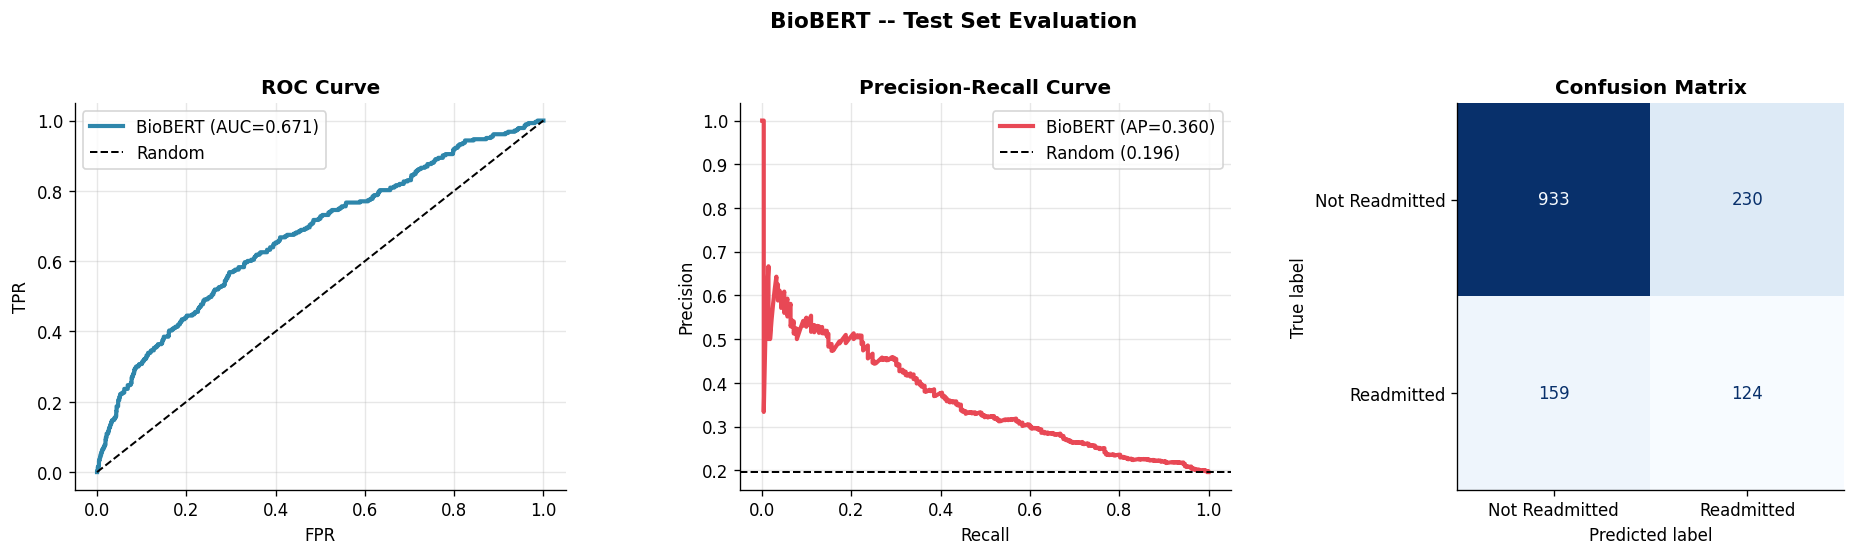

In [9]:
# Test Set Prediction
pred_out = trainer.predict(test_ds)

# Logits, Predicted Labels, and Probabilities
logits = pred_out.predictions
y_pred = np.argmax(logits, axis=-1)

y_prob = torch.softmax(
    torch.tensor(logits, dtype=torch.float32),
    dim=-1
).numpy()[:, 1]

# Evaluation Metrics (Test Set)
roc_auc = roc_auc_score(y_test, y_prob)
pr_auc  = average_precision_score(y_test, y_prob)

report = classification_report(
    y_test,
    y_pred,
    output_dict=True,
    zero_division=0
)

# Results Output
print('\n=== BioBERT -- Test Set Results ===')
print(classification_report(
    y_test,
    y_pred,
    target_names=['Not Readmitted', 'Readmitted'],
    zero_division=0
))
print(f'ROC-AUC : {roc_auc:.4f}   PR-AUC : {pr_auc:.4f}')

# Curve Computation (ROC and Precision-Recall)
fpr, tpr, _  = roc_curve(y_test, y_prob)
prec, rec, _ = precision_recall_curve(y_test, y_prob)

# Plot Evaluation Metrics
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# ROC Curve
axes[0].plot(
    fpr, tpr,
    color=PALETTE[0],
    lw=2.5,
    label=f'BioBERT (AUC={roc_auc:.3f})'
)
axes[0].plot([0, 1], [0, 1], 'k--', lw=1.2, label='Random')
axes[0].set_title('ROC Curve', fontweight='bold')
axes[0].set_xlabel('FPR')
axes[0].set_ylabel('TPR')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Precision-Recall Curve
axes[1].plot(
    rec, prec,
    color=PALETTE[1],
    lw=2.5,
    label=f'BioBERT (AP={pr_auc:.3f})'
)
axes[1].axhline(
    y=y_test.mean(),
    color='k',
    linestyle='--',
    lw=1.2,
    label=f'Random ({y_test.mean():.3f})'
)
axes[1].set_title('Precision-Recall Curve', fontweight='bold')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Confusion Matrix
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=['Not Readmitted', 'Readmitted']
).plot(ax=axes[2], colorbar=False, cmap='Blues')

axes[2].set_title('Confusion Matrix', fontweight='bold')

# Figure Formatting and Save
plt.suptitle(
    'BioBERT -- Test Set Evaluation',
    fontsize=13,
    fontweight='bold',
    y=1.02
)
plt.tight_layout()

plt.savefig(
    f'{BIOBERT_PLOTS_DIR}/bio_02_test_evaluation.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

## Prediction Confidence Analysis

This section analyses the distribution of predicted probabilities to assess model confidence and error behaviour.

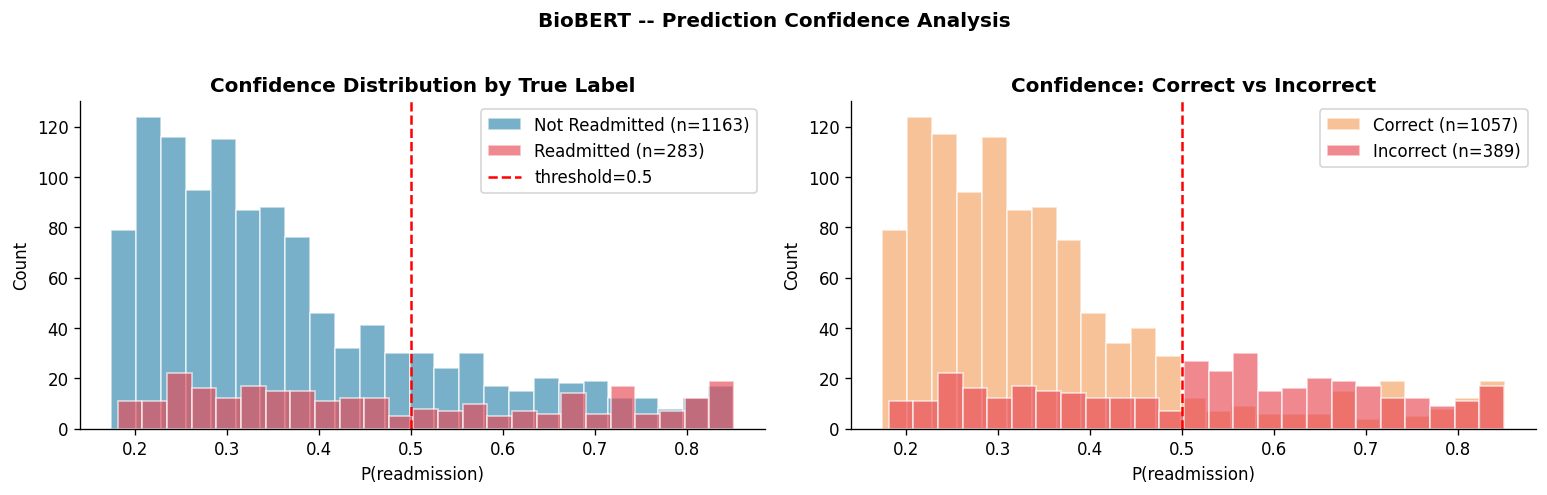

In [10]:
# Confidence Distribution Plots
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Confidence by True Label
for label, color, name in [
    (0, PALETTE[0], 'Not Readmitted'),
    (1, PALETTE[1], 'Readmitted')
]:
    sub = y_prob[y_test == label]

    axes[0].hist(
        sub,
        bins=25,
        alpha=0.65,
        color=color,
        edgecolor='white',
        label=f'{name} (n={len(sub)})'
    )

# Decision Threshold Line
axes[0].axvline(
    0.5,
    color='red',
    linestyle='--',
    lw=1.5,
    label='threshold=0.5'
)

axes[0].set_title('Confidence Distribution by True Label', fontweight='bold')
axes[0].set_xlabel('P(readmission)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Confidence by Prediction Correctness
correct = (y_pred == y_test)

for flag, color, lbl in [
    (True,  PALETTE[2], 'Correct'),
    (False, PALETTE[1], 'Incorrect')
]:
    sub = y_prob[correct == flag]

    axes[1].hist(
        sub,
        bins=25,
        alpha=0.65,
        color=color,
        edgecolor='white',
        label=f'{lbl} (n={len(sub)})'
    )

# Decision Threshold Line
axes[1].axvline(
    0.5,
    color='red',
    linestyle='--',
    lw=1.5
)

axes[1].set_title('Confidence: Correct vs Incorrect', fontweight='bold')
axes[1].set_xlabel('P(readmission)')
axes[1].set_ylabel('Count')
axes[1].legend()

# Figure Formatting and Save
plt.suptitle(
    'BioBERT -- Prediction Confidence Analysis',
    fontsize=12,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()

plt.savefig(
    f'{BIOBERT_PLOTS_DIR}/bio_03_confidence_analysis.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

## Results Persistence and Resource Cleanup

This section saves evaluation outputs and releases all GPU memory. This is the final transformer notebook — after completion, proceed to Notebook 06 for cross-model evaluation.

In [11]:
# Save Evaluation Metrics to CSV
pd.DataFrame([{
    'Model'         : 'BioBERT',
    'Model_ID'      : BIOBERT_MODEL_ID,
    'Type'          : 'Transformer',
    'Domain'        : 'Biomedical (BERT-base-cased + continued pretraining on PubMed + PMC)',
    'Accuracy'      : report['accuracy'],
    'Precision_Pos' : report['1']['precision'],
    'Recall_Pos'    : report['1']['recall'],
    'F1_Pos'        : report['1']['f1-score'],
    'F1_Weighted'   : report['weighted avg']['f1-score'],
    'ROC_AUC'       : roc_auc,
    'PR_AUC'        : pr_auc,
}]).to_csv(
    BIOBERT_RESULTS_CSV,
    index=False
)

print(f'Metrics  -> {BIOBERT_RESULTS_CSV}')


# Save Predictions and Evaluation Artifacts (Pickle)
with open(BIOBERT_PREDS_PKL, 'wb') as f:
    pickle.dump({
        'y_test'  : y_test,
        'y_pred'  : y_pred,
        'y_prob'  : y_prob,
        'X_test'  : X_test,
        'report'  : report,
        'roc_auc' : roc_auc,
        'pr_auc'  : pr_auc,
        'fpr'     : fpr,
        'tpr'     : tpr,
        'prec'    : prec,
        'rec'     : rec,
    }, f)

print(f'Preds    -> {BIOBERT_PREDS_PKL}')


# Resource Cleanup
import gc
del model, trainer
gc.collect()

if device.type == 'cuda':
    torch.cuda.empty_cache()
    torch.cuda.synchronize()
    print(f'VRAM after cleanup : {torch.cuda.memory_allocated(0)/1e9:.2f} GB')


# Final Metric Summary
print(f'\nROC-AUC : {roc_auc:.4f}  |  PR-AUC : {pr_auc:.4f}')
print('Done. Proceed to 06_evaluation_results.ipynb')

Metrics  -> D:\Lancaster University Coursework\Term 2\SCC 453 - Natural Language Processing and Language Models\Coursework Code\using mimic data\medical_nlp_deterioration\results\metrics\biobert_results.csv
Preds    -> D:\Lancaster University Coursework\Term 2\SCC 453 - Natural Language Processing and Language Models\Coursework Code\using mimic data\medical_nlp_deterioration\data\processed\preds_biobert.pkl
VRAM after cleanup : 0.02 GB

ROC-AUC : 0.6711  |  PR-AUC : 0.3598
Done. Proceed to 06_evaluation_results.ipynb
